# Microsft Bing Image Search Download

Using Microsoft Bing to download images of different foods.

Source: https://docs.microsoft.com/en-us/azure/cognitive-services/bing-image-search/quickstarts/python

**Note:** The docs link above says to use `"https://api.cognitive.microsoft.com/bing/v7.0/images/search"` as the search API URL but due to API changes, the correct link to use is `"https://api.bing.microsoft.com/v7.0/images/search"`. This is true for API instances made after October 30, 2020.

In [1]:
import requests
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import streamlit as st

# subscription_key = st.secrets["pexels_api_key"]
try:
    API_KEY = st.secrets["pexels_api_key"]
except Exception:
    import tomllib  # Fallback for manual local parsing
    with open(SECRETS_PATH, "rb") as f:
        config = tomllib.load(f)
        API_KEY = config["pexels_api_key"]

# search_url = "https://api.cognitive.microsoft.com/bing/v7.0/images/search" # OLD
search_url = "https://api.pexels.com/v1/search" # New (after Oct 30, 2020)


In [2]:
headers = {"Authorization" : API_KEY}

## Create and send a search request

In [3]:
search_term = "apple"

# See list of params here - https://docs.microsoft.com/en-us/bing/search-apis/bing-image-search/reference/query-parameters 
params = {
    "query": search_term,
    "per_page": 16 # This tells Pexels to just return 16 images directly
}

In [4]:
response = requests.get(search_url, headers=headers, params=params)
response.raise_for_status() # used for debugging
search_results = response.json()

# Pexels stores the list in 'photos' and the image sizes in 'src'
thumbnail_urls = [img["src"]["medium"] for img in search_results["photos"]]

In [5]:
search_results

{'page': 1,
 'per_page': 16,
 'photos': [{'id': 28710026,
   'width': 2339,
   'height': 3316,
   'url': 'https://www.pexels.com/photo/fresh-red-apples-at-melbourne-market-28710026/',
   'photographer': 'Joolsmagools  ®️',
   'photographer_url': 'https://www.pexels.com/@joolsmagools',
   'photographer_id': 1051252906,
   'avg_color': '#A4462C',
   'src': {'original': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg',
    'large2x': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg?auto=compress&cs=tinysrgb&dpr=2&h=650&w=940',
    'large': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg?auto=compress&cs=tinysrgb&h=650&w=940',
    'medium': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg?auto=compress&cs=tinysrgb&h=350',
    'small': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg?auto=compress&cs=tinysrgb&h=130',
    'portrait': 'https://images.pexels.com/photos/28710026/pexels-pho

In [6]:
# The length of "value" parameter will be set by the "count" parameter:
# see: https://docs.microsoft.com/en-us/bing/search-apis/bing-image-search/reference/query-parameters
# Min: 35, Max: 150
len(search_results["photos"])

16

In [7]:
search_results["photos"][0]

{'id': 28710026,
 'width': 2339,
 'height': 3316,
 'url': 'https://www.pexels.com/photo/fresh-red-apples-at-melbourne-market-28710026/',
 'photographer': 'Joolsmagools  ®️',
 'photographer_url': 'https://www.pexels.com/@joolsmagools',
 'photographer_id': 1051252906,
 'avg_color': '#A4462C',
 'src': {'original': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg',
  'large2x': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg?auto=compress&cs=tinysrgb&dpr=2&h=650&w=940',
  'large': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg?auto=compress&cs=tinysrgb&h=650&w=940',
  'medium': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg?auto=compress&cs=tinysrgb&h=350',
  'small': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg?auto=compress&cs=tinysrgb&h=130',
  'portrait': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg?auto=compress&cs=tinysrgb&fit=crop&h=1200&w=800',


In [8]:
# We can save metadata from our image so we can look it up later
attributes_from_value = ["width", "height", "contentURL"] 
attributes_to_create = ["date_created", "source"]

In [9]:
# Get current time
import datetime
current_time = datetime.datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )
current_time

'2026-08-09 12:24:36'

## View images

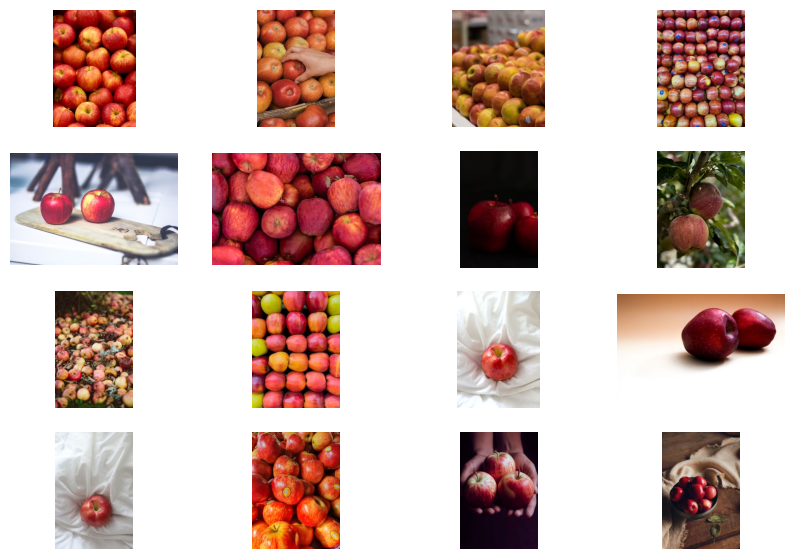

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(10, 7))
for i in range(4):
    for j in range (4):
        image_data = requests.get(thumbnail_urls[i+4*j]) # downloads as bytes
        image_data.raise_for_status()
        image = Image.open(BytesIO(image_data.content))
        axes[i][j].imshow(image)
        axes[i][j].axis("off")
plt.show()

## Downloading an image

In [11]:
image = requests.get("https://pixnio.com/free-images/2017/11/10/2017-11-10-21-27-56.jpg")
open("downloaded_img.jpg", "wb").write(image.content)

1242

## Getting URLs for multiple images (for different search terms)

Let's write some code to get a bunch of images downloaded (we can turn the following into a script later).

In [12]:
# # Original search terms
# search_terms = ['apple',
#  'banana',
#  'beef',
#  'blueberries',
#  'carrots',
#  'chicken_wings',
#  'egg',
#  'honey',
#  'mushrooms',
#  'strawberries']

# New search terms (V2)
search_terms = [
    # =========================
    # FRUITS - 25
    # =========================
    'apple',
    'banana',
    'blueberries',
    'strawberries',
    'orange fruit',
    'mango fruit',
    'pineapple',
    'watermelon',
    'grapes',
    'pear fruit',
    'peach fruit',
    'kiwi fruit',
    'papaya fruit',
    'avocado',
    'pomegranate',
    'cherries',
    'raspberries',
    'blackberries',
    'cantaloupe melon',
    'grapefruit',
    'plum fruit',
    'apricot fruit',
    'figs fruit',
    'dates fruit',
    'coconut',

    # =========================
    # VEGETABLES - 25
    # =========================
    'carrots',
    'mushrooms',
    'broccoli',
    'cauliflower',
    'cabbage',
    'spinach',
    'lettuce',
    'cucumber',
    'tomato',
    'bell pepper',
    'onion',
    'garlic',
    'potato',
    'sweet potato',
    'pumpkin',
    'zucchini',
    'eggplant',
    'asparagus',
    'celery',
    'green beans',
    'peas',
    'corn',
    'beetroot',
    'radish',
    'turnip',

    # =========================
    # MEAT / SEAFOOD / EGG - 20
    # =========================
    'beef meat',
    'chicken wings',
    'egg',
    'chicken breast',
    'chicken thigh',
    'pork chop',
    'bacon',
    'turkey breast',
    'salmon fish',
    'tuna fish',
    'shrimp',
    'crab',
    'lobster',
    'squid',
    'cod fish',
    'sardines',
    'tilapia fish',
    'lamb chop',
    'duck breast',
    'ham',

    # =========================
    # LEGUMES / NUTS / SEEDS - 15
    # =========================
    'tofu',
    'lentils',
    'chickpeas',
    'kidney beans',
    'black beans',
    'peanuts',
    'almonds',
    'cashews',
    'walnuts',
    'pistachios',
    'sunflower seeds',
    'pumpkin seeds',
    'sesame seeds',
    'chia seeds',
    'soybeans',

    # =========================
    # DAIRY / GRAINS / OTHER - 15
    # =========================
    'honey',
    'milk',
    'yogurt',
    'cheddar cheese',
    'mozzarella cheese',
    'butter',
    'rice',
    'brown rice',
    'oats',
    'bread',
    'pasta',
    'noodles',
    'bagel',
    'popcorn',
    'peanut butter',
]

In [13]:
"[INFO] Making directory: data/100_foods...\n",

('[INFO] Making directory: data/100_foods...\n',)

# TODO
* Batch save images
* Batch delete images
* Add image metadata to CSV (for logging and exporting later)

In [14]:
import uuid
import datetime
import requests

# 1. Force this cell to use Pexels instead of Bing
SEARCH_URL = "https://api.pexels.com/v1/search"
headers = {"Authorization": st.secrets["pexels_api_key"]}
COUNT = 80  # Pexels max per page
img_to_download_list = []
for search_term in search_terms:

    # Fixed a minor bug here so it prints the actual word instead of the literal string 'search_term'
    print(f"\n[INFO] Searching for '{search_term}' images...")
    
    # 2. Update parameters for Pexels ('query' instead of 'q', 'per_page' instead of 'count')
    # Note: Pexels allows a maximum COUNT of 80 per request
    params = {
        "query": search_term,
        "per_page": COUNT 
    }
    
    response = requests.get(SEARCH_URL, 
                            headers=headers, 
                            params=params)
    response.raise_for_status() # used for debugging
    search_results = response.json()

    # 3. Pexels uses 'total_results' instead of 'totalEstimatedMatches'
    print(f"[INFO] Found {search_results['total_results']} potential image matches...")
    print("[INFO] Appending image URLs to dictionary... \n")
    
    # 4. Pexels stores the list of images in 'photos' instead of 'value'
    for i, value in enumerate(search_results["photos"]):
        img_metadata = {}

        # Give each image a UUID
        img_metadata["image_id"] = str(uuid.uuid4())

        # State the source of the image
        img_metadata["source"] = "pexels_api_v1"
        
        # Collect metadata about each image
        img_metadata["search_term"] = search_term
        
        # 5. Pexels nests image URLs inside a 'src' dictionary. 
        # Using 'original' gets you the full high-res image.
        img_metadata["img_url"] = value["src"]["original"] 
        img_metadata["height"] = value["height"]
        img_metadata["width"] = value["width"]
        img_metadata["time_downloaded"] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        
        img_to_download_list.append(img_metadata)
        if i % 50 == 0:
            print(f"[INFO] Adding image url for '{search_term}': {img_metadata['img_url']}...")

img_to_download_list


[INFO] Searching for 'apple' images...
[INFO] Found 8000 potential image matches...
[INFO] Appending image URLs to dictionary... 

[INFO] Adding image url for 'apple': https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg...
[INFO] Adding image url for 'apple': https://images.pexels.com/photos/30851810/pexels-photo-30851810.jpeg...

[INFO] Searching for 'banana' images...
[INFO] Found 8000 potential image matches...
[INFO] Appending image URLs to dictionary... 

[INFO] Adding image url for 'banana': https://images.pexels.com/photos/37182860/pexels-photo-37182860.jpeg...
[INFO] Adding image url for 'banana': https://images.pexels.com/photos/7195347/pexels-photo-7195347.jpeg...

[INFO] Searching for 'blueberries' images...
[INFO] Found 7700 potential image matches...
[INFO] Appending image URLs to dictionary... 

[INFO] Adding image url for 'blueberries': https://images.pexels.com/photos/583837/pexels-photo-583837.jpeg...
[INFO] Adding image url for 'blueberries': https:/

[{'image_id': 'e45b6f8e-ffdb-4bfa-9154-0a7780f54c91',
  'source': 'pexels_api_v1',
  'search_term': 'apple',
  'img_url': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg',
  'height': 3316,
  'width': 2339,
  'time_downloaded': '2026-08-09 12:24:46'},
 {'image_id': '88de92c2-c910-4c79-9720-f93b56a8994e',
  'source': 'pexels_api_v1',
  'search_term': 'apple',
  'img_url': 'https://images.pexels.com/photos/5960/healthy-wood-red-apple.jpg',
  'height': 3648,
  'width': 5472,
  'time_downloaded': '2026-08-09 12:24:46'},
 {'image_id': 'fe257f2c-545e-4d08-a93c-b928707f9236',
  'source': 'pexels_api_v1',
  'search_term': 'apple',
  'img_url': 'https://images.pexels.com/photos/34282667/pexels-photo-34282667.jpeg',
  'height': 5260,
  'width': 3500,
  'time_downloaded': '2026-08-09 12:24:46'},
 {'image_id': 'b7283e30-78e2-48c3-b98b-2863ded19575',
  'source': 'pexels_api_v1',
  'search_term': 'apple',
  'img_url': 'https://images.pexels.com/photos/31663870/pexels-photo-3166

In [ ]:
# Download images to disk (with checkpoint resuming + progress tracking)
import os
import json
import time
from io import BytesIO
from PIL import Image
Image.MAX_IMAGE_PIXELS = None  # Allow large Pexels images (we resize them)
from requests import exceptions

DOWNLOAD_DIR = r"C:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\data\100_foods"
CHECKPOINT_FILE = os.path.join(DOWNLOAD_DIR, "_checkpoint.json")
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

# Load checkpoint to track completed downloads
completed = set()
skipped = 0
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "r") as f:
        completed = set(json.load(f))
    skipped = len(completed)
    print(f"[INFO] Resuming from checkpoint: {skipped} images already downloaded")

total = len(img_to_download_list)
failed = 0
current_food = ""
print(f"[INFO] Downloading {total} images ({skipped} done, {total - skipped} remaining)...\n")

start_time = time.time()
last_report_time = start_time

for i, img in enumerate(img_to_download_list):
    search_term = img["search_term"]
    image_id = img["image_id"]

    # Detect when we start a new food
    if search_term != current_food:
        current_food = search_term
        food_start = time.time()

    # Skip if already in checkpoint
    if image_id in completed:
        continue

    img_url = img["img_url"]

    # Create subfolder per food (sanitize folder name)
    folder_name = search_term.replace(" ", "_").replace("/", "_")
    folder = os.path.join(DOWNLOAD_DIR, folder_name)
    os.makedirs(folder, exist_ok=True)

    save_path = os.path.join(folder, f"{image_id}.jpg")

    # Track download time for this image
    start_dl = time.time()
    try:
        r = requests.get(img_url, timeout=30)
        r.raise_for_status()
        # Resize on-the-fly: full-res → 380x380 JPEG
        img = Image.open(BytesIO(r.content))
        img = img.resize((380, 380), Image.LANCZOS)
        img.save(save_path, "JPEG", quality=85, optimize=True)
        completed.add(image_id)
    except Exception as e:
        failed += 1
        if failed <= 5:
            print(f"[WARN] Failed '{search_term}': {type(e).__name__}")
        continue

    # --- Progress report every 25 downloads or every 10 seconds ---
    newly_downloaded = len(completed) - skipped
    elapsed = time.time() - start_time
    now = time.time()

    if newly_downloaded % 25 == 0 or (now - last_report_time) > 10:
        last_report_time = now

        # Calculate speed & ETA
        speed = newly_downloaded / elapsed if elapsed > 0 else 0
        remaining = total - len(completed) - failed
        eta_seconds = remaining / speed if speed > 0 else 0

        # Format ETA
        if eta_seconds < 60:
            eta_str = f"{eta_seconds:.0f}s"
        elif eta_seconds < 3600:
            eta_str = f"{eta_seconds/60:.1f} min"
        else:
            eta_str = f"{eta_seconds/3600:.1f} hr"

        # Format elapsed
        if elapsed < 60:
            elapsed_str = f"{elapsed:.0f}s"
        elif elapsed < 3600:
            elapsed_str = f"{elapsed/60:.1f} min"
        else:
            elapsed_str = f"{elapsed/3600:.1f} hr"

        pct = len(completed) / total * 100
        bar_len = 20
        filled = int(bar_len * len(completed) / total)
        bar = "█" * filled + "░" * (bar_len - filled)

        print(f"[{bar}] {pct:5.1f}% |{len(completed):>5}/{total} done | {failed:>3} failed"
              f" | {speed:.1f} img/s | ⏱ {elapsed_str} elapsed | ⏳ {eta_str} remaining"
              f" | 🍽 {current_food}")

    # Save checkpoint every 50 downloads
    if newly_downloaded % 50 == 0:
        with open(CHECKPOINT_FILE, "w") as f:
            json.dump(list(completed), f)

# Final checkpoint save
with open(CHECKPOINT_FILE, "w") as f:
    json.dump(list(completed), f)

total_elapsed = time.time() - start_time
if total_elapsed < 60:
    total_str = f"{total_elapsed:.0f}s"
elif total_elapsed < 3600:
    total_str = f"{total_elapsed/60:.1f} min"
else:
    total_str = f"{total_elapsed/3600:.1f} hr"

print(f"\n{'='*60}")
print(f"[DONE] {len(completed)}/{total} images downloaded to {DOWNLOAD_DIR}")
print(f"[INFO] Failed: {failed} | Duration: {total_str} | Checkpoint saved")

[INFO] Resuming from checkpoint: 1000 images already downloaded
[INFO] Downloading 7979 images (1000 done, 6979 remaining)...

[██░░░░░░░░░░░░░░░░░░]  12.8% | 1022/7979 done |   0 failed | 2.1 img/s | ⏱ 11s elapsed | ⏳ 55.8 min remaining | 🍽 apple
[██░░░░░░░░░░░░░░░░░░]  12.8% | 1025/7979 done |   0 failed | 1.7 img/s | ⏱ 15s elapsed | ⏳ 1.2 hr remaining | 🍽 apple
[██░░░░░░░░░░░░░░░░░░]  13.0% | 1035/7979 done |   0 failed | 1.4 img/s | ⏱ 25s elapsed | ⏳ 1.4 hr remaining | 🍽 apple
[██░░░░░░░░░░░░░░░░░░]  13.2% | 1050/7979 done |   0 failed | 1.4 img/s | ⏱ 35s elapsed | ⏳ 1.3 hr remaining | 🍽 apple
[██░░░░░░░░░░░░░░░░░░]  13.4% | 1069/7979 done |   0 failed | 1.5 img/s | ⏱ 45s elapsed | ⏳ 1.3 hr remaining | 🍽 apple
[██░░░░░░░░░░░░░░░░░░]  13.5% | 1075/7979 done |   0 failed | 1.5 img/s | ⏱ 49s elapsed | ⏳ 1.3 hr remaining | 🍽 apple
[██░░░░░░░░░░░░░░░░░░]  13.6% | 1086/7979 done |   0 failed | 1.4 img/s | ⏱ 1.0 min elapsed | ⏳ 1.3 hr remaining | 🍽 banana
[WARN] Failed 'banana': HTTPError

In [35]:
import pandas as pd
targ_img_df = pd.DataFrame(img_to_download_list)
targ_img_df

,image_id,source,search_term,img_url,height,width,time_downloaded
0,e45b6f8e-ffdb-4bfa-9154-0a7780f54c91,pexels_api_v1,apple,https://images.pexels.com/photos/28710026/pexe...,3316,2339,2026-08-09 12:24:46
1,88de92c2-c910-4c79-9720-f93b56a8994e,pexels_api_v1,apple,https://images.pexels.com/photos/5960/healthy-...,3648,5472,2026-08-09 12:24:46
2,fe257f2c-545e-4d08-a93c-b928707f9236,pexels_api_v1,apple,https://images.pexels.com/photos/34282667/pexe...,5260,3500,2026-08-09 12:24:46
3,b7283e30-78e2-48c3-b98b-2863ded19575,pexels_api_v1,apple,https://images.pexels.com/photos/31663870/pexe...,4160,2768,2026-08-09 12:24:46
4,49f9646d-79b1-468a-9801-803f19f2be6c,pexels_api_v1,apple,https://images.pexels.com/photos/8805439/pexel...,6000,4000,2026-08-09 12:24:46
...,...,...,...,...,...,...,...
7974,58e86322-7298-4754-a676-992323e5a240,pexels_api_v1,peanut butter,https://images.pexels.com/photos/35237495/pexe...,2644,4470,2026-08-09 12:25:06
7975,ab37102d-d7c0-4cfa-90cd-7c88edfe8c56,pexels_api_v1,peanut butter,https://images.pexels.com/photos/33210290/pexe...,6000,4000,2026-08-09 12:25:06
7976,2998689f-a233-4ef9-a64e-3034a9d03c66,pexels_api_v1,peanut butter,https://images.pexels.com/photos/5652274/pexel...,4000,6000,2026-08-09 12:25:06
7977,f23075dc-6d28-42a0-b283-b923ebc4a3e5,pexels_api_v1,peanut butter,https://images.pexels.com/photos/28042787/pexe...,4032,2268,2026-08-09 12:25:06


In [36]:
# # Create the 'data' directory if it doesn't exist yet
# os.makedirs("data", exist_ok=True)

# # Save the dataframe to the CSV
# targ_img_df.to_csv("data/100_target_images_metadata.csv", index=False)
import os
BASE_DIR = r"C:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\data_exploration\data"
SECRETS_PATH = r"C:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\.streamlit\secrets.toml"
TARG_DIR = os.path.join(BASE_DIR, "100_foods")

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(TARG_DIR, exist_ok=True)

In [37]:
len(targ_img_df)

7979

## Downloading data for multiple URLs

Now we have a bunch of URLs, let's download data.

In [38]:
# List of exceptions, source: https://www.pyimagesearch.com/2018/04/09/how-to-quickly-build-a-deep-learning-image-dataset/
from requests import exceptions
EXCEPTIONS = set([IOError, FileNotFoundError,
	exceptions.RequestException, exceptions.HTTPError,
	exceptions.ConnectionError, exceptions.Timeout])

In [39]:
img_to_download_list[0]

{'image_id': 'e45b6f8e-ffdb-4bfa-9154-0a7780f54c91',
 'source': 'pexels_api_v1',
 'search_term': 'apple',
 'img_url': 'https://images.pexels.com/photos/28710026/pexels-photo-28710026.jpeg',
 'height': 3316,
 'width': 2339,
 'time_downloaded': '2026-08-09 12:24:46'}

## Download images

In [40]:
TARG_DIR = r"C:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\data\100_foods"

## TODO: Delete images that don't work

TODO:
* Scan through downloaded images and if they don't work, delete them.
    * See this for scanning through directories to get subpath names: https://stackoverflow.com/a/2909998/7900723
* Also delete them from the CSV metadata file.

```python
# Pseudocode
for img_path in img_paths:
    try:
        open(img_path)

    # If it doesn't open, delete the image...
    except:
        os.remove(img_path)
        # CODE HERE TO DELTE FROM CSV FILE AS WELL???
        continue
```

In [ ]:
import os
import pathlib

img_files_to_check = []
for path, subdirs, files in os.walk(TARG_DIR):
    for name in files:
        if name.lower().endswith((".jpg", ".jpeg", ".png")):
            img_files_to_check.append(pathlib.Path(path, name))

print(f"Found {len(img_files_to_check)} image files to verify")

In [42]:
# .stem gets the filename from a PosixPath (Path datatype) 
img_files_to_check[0].stem

'00a87bab-6cd1-436f-86b4-a778dac50fc1'

In [43]:
broken_images = []
for img_file_path in img_files_to_check:
    # Check images downloaded and delete if bogus
    # try:
    #     image_id = img_file_path.stem # get image id
    #     Image.open(img_file_path) # if this fails, the target image should be deleted... 
    # except Exception as e:
    #     broken_images.append(image_id)
    #     print(f"Image: {image_id} is broken because: {e}...")
    #     print(f"Deleting image... total images removed: {len(broken_images)}")
    #     os.remove(img_file_path)
            # continue
    try:
        image_id = img_file_path.stem
        with Image.open(img_file_path) as img:
            img.verify() # Validates internal byte alignment safely
    except Exception as e:
        broken_images.append(image_id)
        print(f"Image: {image_id} is broken because: {e}...")
        try:
            os.remove(img_file_path) # Deletes without system file-lock conflicts
        except OSError:
            pass


c:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\food-vision\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (105657838 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
c:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\food-vision\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (106064748 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
c:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\food-vision\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (105942890 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
c:\1.My Files\Paing Lin Htike\School\Semester-8\CS - 601\Nutrify\food-vision\Lib\site-packages\PIL\Image.py:3574: DecompressionBombWarning: Image size (108576768 pixels) exceeds limit of 89478485 pixels, could be deco

In [44]:
broken_images[:10]

[]

This error occurs when PIL.Image can't open a file:

```
UnidentifiedImageError: cannot identify image file '10_whole_foods_test/apple/47a052b0-c5ee-4e42-9352-0b4f278d0e6d.jpg'
```

So we can use an exception to skip/delete it when it comes across it.

UPTOHERE:

another error appears...

```
Deleting image: 10_whole_foods_test/banana/1d5388dd-01c2-4aae-b7b0-d09f0e7e67f6.jpg due to cannot identify image file '10_whole_foods_test/banana/1d5388dd-01c2-4aae-b7b0-d09f0e7e67f6.jpg'...
Deleting image: 10_whole_foods_test/banana/1d5388dd-01c2-4aae-b7b0-d09f0e7e67f6.jpg due to [Errno 2] No such file or directory: '10_whole_foods_test/banana/1d5388dd-01c2-4aae-b7b0-d09f0e7e67f6.jpg'...
```

Looks like it doubled up on itself? 

Could remove that code and then check the directory once it's done and delete any images that are corrupt:

1. Save all images to directory (batch save)
2. Scan all saved images and delete if corrupt (batch delete)
3. Move to next class...

```python
 Check images downloaded and delete if bogus
        try:
            Image.open(save_path)
            
        except Exception as e:
            print(f"Deleting image: {save_path} due to {e}...")
            os.remove(save_path)
            continue
```

## TODO: Update metadata to reflect deleted images

In [45]:
print("1. Search terms:", search_terms)
print("2. Total images collected in list:", len(img_to_download_list))
print("3. DataFrame rows and columns:", targ_img_df.shape)

1. Search terms: ['apple', 'banana', 'blueberries', 'strawberries', 'orange fruit', 'mango fruit', 'pineapple', 'watermelon', 'grapes', 'pear fruit', 'peach fruit', 'kiwi fruit', 'papaya fruit', 'avocado', 'pomegranate', 'cherries', 'raspberries', 'blackberries', 'cantaloupe melon', 'grapefruit', 'plum fruit', 'apricot fruit', 'figs fruit', 'dates fruit', 'coconut', 'carrots', 'mushrooms', 'broccoli', 'cauliflower', 'cabbage', 'spinach', 'lettuce', 'cucumber', 'tomato', 'bell pepper', 'onion', 'garlic', 'potato', 'sweet potato', 'pumpkin', 'zucchini', 'eggplant', 'asparagus', 'celery', 'green beans', 'peas', 'corn', 'beetroot', 'radish', 'turnip', 'beef meat', 'chicken wings', 'egg', 'chicken breast', 'chicken thigh', 'pork chop', 'bacon', 'turkey breast', 'salmon fish', 'tuna fish', 'shrimp', 'crab', 'lobster', 'squid', 'cod fish', 'sardines', 'tilapia fish', 'lamb chop', 'duck breast', 'ham', 'tofu', 'lentils', 'chickpeas', 'kidney beans', 'black beans', 'peanuts', 'almonds', 'cashew

In [46]:
import pandas as pd
targ_img_df = pd.DataFrame(img_to_download_list)

In [47]:
targ_img_df.head()

,image_id,source,search_term,img_url,height,width,time_downloaded
0,e45b6f8e-ffdb-4bfa-9154-0a7780f54c91,pexels_api_v1,apple,https://images.pexels.com/photos/28710026/pexe...,3316,2339,2026-08-09 12:24:46
1,88de92c2-c910-4c79-9720-f93b56a8994e,pexels_api_v1,apple,https://images.pexels.com/photos/5960/healthy-...,3648,5472,2026-08-09 12:24:46
2,fe257f2c-545e-4d08-a93c-b928707f9236,pexels_api_v1,apple,https://images.pexels.com/photos/34282667/pexe...,5260,3500,2026-08-09 12:24:46
3,b7283e30-78e2-48c3-b98b-2863ded19575,pexels_api_v1,apple,https://images.pexels.com/photos/31663870/pexe...,4160,2768,2026-08-09 12:24:46
4,49f9646d-79b1-468a-9801-803f19f2be6c,pexels_api_v1,apple,https://images.pexels.com/photos/8805439/pexel...,6000,4000,2026-08-09 12:24:46


In [48]:
# Remove broken images from targ_img_df
# Look at the targ img df and filter for images "not in" the broken images
targ_img_df_good = targ_img_df[~targ_img_df["image_id"].isin(broken_images)]
targ_img_df_good.head()

,image_id,source,search_term,img_url,height,width,time_downloaded
0,e45b6f8e-ffdb-4bfa-9154-0a7780f54c91,pexels_api_v1,apple,https://images.pexels.com/photos/28710026/pexe...,3316,2339,2026-08-09 12:24:46
1,88de92c2-c910-4c79-9720-f93b56a8994e,pexels_api_v1,apple,https://images.pexels.com/photos/5960/healthy-...,3648,5472,2026-08-09 12:24:46
2,fe257f2c-545e-4d08-a93c-b928707f9236,pexels_api_v1,apple,https://images.pexels.com/photos/34282667/pexe...,5260,3500,2026-08-09 12:24:46
3,b7283e30-78e2-48c3-b98b-2863ded19575,pexels_api_v1,apple,https://images.pexels.com/photos/31663870/pexe...,4160,2768,2026-08-09 12:24:46
4,49f9646d-79b1-468a-9801-803f19f2be6c,pexels_api_v1,apple,https://images.pexels.com/photos/8805439/pexel...,6000,4000,2026-08-09 12:24:46


In [49]:
len(targ_img_df_good)

7979

## Verify that images in saved folder are in metadata csv

In [50]:
# !rm 10_whole_foods_test/.DS_Store

In [51]:
TARG_DIR

'C:\\1.My Files\\Paing Lin Htike\\School\\Semester-8\\CS - 601\\Nutrify\\data\\100_foods'

In [59]:
# Get list of saved images (only .jpg files, skip checkpoint)
import os
import pathlib

saved_image_ids = []
for path, subdirs, files in os.walk(TARG_DIR):
    for name in files:
        if name.lower().endswith((".jpg", ".jpeg", ".png")):
            saved_image_ids.append(pathlib.Path(path, name).stem)

print(f"Images on disk: {len(saved_image_ids)}")
print(f"Images in DataFrame: {len(targ_img_df_good)}")

# Filter DataFrame to only include images that exist on disk
targ_img_df_good = targ_img_df_good[targ_img_df_good["image_id"].isin(saved_image_ids)]

# Show mismatch info instead of crashing
on_disk_only = set(saved_image_ids) - set(targ_img_df_good["image_id"].tolist())
in_df_only = set(targ_img_df["image_id"].tolist()) - set(saved_image_ids)
print(f"On disk but not in CSV: {len(on_disk_only)}")
print(f"In CSV but not on disk: {len(in_df_only)} (likely failed downloads)")
print(f"Final clean count: {len(targ_img_df_good)}")

Images on disk: 9009
Images in DataFrame: 7978
On disk but not in CSV: 1031
In CSV but not on disk: 1 (likely failed downloads)
Final clean count: 7978


## Export the metadata CSV for later use

In [60]:
import os
targ_img_df_good.to_csv("../data/100_foods_metada_updated.csv", index=False)